![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# CSCK506 Deep Learning: END-MODULE ASSIGNMENT

Pneumonia is an inflammatory condition of the lungs and remains a common and potentially serious disease worldwide. Early and accurate diagnosis is essential for effective treatment, yet traditional methods—such as manual interpretation of chest X-ray images—can be time-consuming and subject to variability among clinicians.

This project explores automated deep learning approaches to detect pneumonia from medical images, with the goal of assisting and improving diagnostic processes.

### Objectives
- Develop models capable of accurately classifying chest X-ray images as NORMAL or PNEUMONIA
- Compare baseline and advanced deep learning approaches
- Evaluate the impact of preprocessing, augmentation, and transfer learning
- Optimize model performance using appropriate metrics (Accuracy, AUC, Precision, Recall, F1-score)


### Project Structure

The project is organized into three main notebooks, each focusing on a key stage of the machine learning pipeline:

1. Exploratory Data Analysis (EDA)
- Understand dataset structure and distribution
- Visualize class imbalance and sample images
- Identify potential challenges (noise, variability, imbalance)

2. Preprocessing & Models (Baselines and Tuned)

- Data preprocessing and pipeline setup
- Model experimentation with three baselines:

        i. Baseline CNN (no augmentation)
        ii. Baseline CNN with data augmentation
        iii. Tuned CNN (optimized hyperparameters)

The goal is to establish strong reference models and understand the impact of basic improvements.

3. Transfer Learning & Model Comparison
- Use pretrained models VGG16 for feature extraction and fine-tuning
- Improve performance through transfer learning
- Compare all models using standardized evaluation metrics
- Analyze trade-offs between performance and complexity

### Expected Outcomes

By the end of this project, we aim to:

- Identify the most effective modeling approach for pneumonia detection
- Quantify the benefits of augmentation and transfer learning
- Provide a clear comparison of all models

Overall, the goal is to develop a reliable and interpretable diagnostic support tool.

In [ ]:
import os
import sys
import json
import random
import pathlib
import importlib.util
import subprocess
import importlib
from datetime import datetime

# Local environments can miss optional tuning deps required by keras-tuner.
for pkg_name in ["tensorboard", "keras-tuner"]:
    if importlib.util.find_spec(pkg_name.replace("-", "_")) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg_name], check=False)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
import keras_tuner as kt
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

In [ ]:
USE_COLAB = True
USE_KAGGLE = False  # Set True when running on Kaggle

In [ ]:
# Configuration
if USE_KAGGLE:

    KAGGLE_HELPERS_PARENT = "/kaggle/input/datasets/omosaad/helpers"
    KAGGLE_HELPERS_DIR = "/kaggle/input/datasets/omosaad/helpers/helpers"

    DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/"
    SAVE_DIR = pathlib.Path("/kaggle/working/saved_models")

    try:
        from helpers import data_utils, model_utils, training_utils, visualization
    except ModuleNotFoundError:
        for p in [KAGGLE_HELPERS_PARENT, KAGGLE_HELPERS_DIR]:
            if os.path.isdir(p) and p not in sys.path:
                sys.path.append(p)
        from helpers import data_utils, model_utils, training_utils, visualization

elif USE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")

    # Point to the folder containing the 'helpers' folder
    sys.path.append('/content/drive/MyDrive/Colab Notebooks')

    from helpers import data_utils, model_utils, training_utils, visualization

    importlib.reload(data_utils)
    importlib.reload(model_utils)
    importlib.reload(training_utils)

else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")  # merged into training pool if present
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
VAL_SPLIT = 0.1
AUTOTUNE = tf.data.AUTOTUNE

SAVE_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_WITHOUT_AUG_CHECKPOINT_PATH = SAVE_DIR / "baseline_without_aug_best_checkpoint.keras"
BASELINE_CHECKPOINT_PATH = SAVE_DIR / "baseline_best_checkpoint.keras"
TUNED_CHECKPOINT_PATH = SAVE_DIR / "baseline_tuned_best_checkpoint.keras"
MODEL_PATH = BASELINE_CHECKPOINT_PATH  # kept for backward compatibility in earlier cells

for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

runtime_name = "Kaggle" if USE_KAGGLE else ("Google Colab" if USE_COLAB else "Local")
print(f"Environment: {runtime_name}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Model artifacts will be stored in: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Google Colab
Dataset root: /content/drive/MyDrive/x-ray-dataset/
Model artifacts will be stored in: /content/drive/MyDrive/saved_models


In [ ]:
# Notebook context
print(f"Runtime mode selected via USE_COLAB={USE_COLAB}.")

Runtime mode selected via USE_COLAB=True.


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## Preprocessing & Baseline+Tuned Models Notebook



<hr style="height:6px;background-color:blue;border:none;">

### Phase 1 - Preprocessing, Oversampling and Data Augmentation

#### 1 - Data Loading and Preprocessing

Create stratified train/validation splits and build `tf.data` pipelines with balanced on-the-fly sampling.

In [ ]:
# Collect all file paths and labels from train plus optional original val directory
all_train_paths, all_train_labels, test_paths, test_labels = data_utils.gather_split_paths_labels(
    TRAIN_DIR,
    TEST_DIR,
    VAL_DIR,
)

print(f"Source pool size (train + optional original val): {len(all_train_paths)} images")

Source pool size (train + optional original val): 5232 images


In [ ]:
# Build train/val/test datasets from helper
train_ds, val_ds, test_ds, dataset_meta = data_utils.build_train_val_test_datasets(
    train_paths=all_train_paths,
    train_labels=all_train_labels,
    test_paths=test_paths,
    test_labels=test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    preprocess_fn=None,
    autotune=AUTOTUNE,
)

train_paths = dataset_meta["train_paths"]
train_labels_raw = dataset_meta["train_labels_raw"]
val_paths = dataset_meta["val_paths"]
val_labels_arr = dataset_meta["val_labels"]
normal_count = dataset_meta["normal_count"]
pneumonia_count = dataset_meta["pneumonia_count"]
steps_per_epoch = dataset_meta["steps_per_epoch"]

print(f"Stratified split (before balancing): {len(train_paths)} train, {len(val_paths)} val")
print(f"  Train before -> NORMAL={normal_count}, PNEUMONIA={pneumonia_count}")
print(f"  Val          -> NORMAL={int((val_labels_arr==0).sum())}, PNEUMONIA={int((val_labels_arr==1).sum())}")
print(f"  Balanced sampling -> NORMAL:PNEUMONIA = 1:1 per epoch")
print(f"  Steps per epoch: {steps_per_epoch}")

class_names = ["NORMAL", "PNEUMONIA"]
print("Class names:", class_names)
print("Note: dataset/val folder excluded; validation split is stratified from dataset/train.")

Stratified split (before balancing): 4708 train, 524 val
  Train before -> NORMAL=1214, PNEUMONIA=3494
  Val          -> NORMAL=135, PNEUMONIA=389
  Balanced sampling -> NORMAL:PNEUMONIA = 1:1 per epoch
  Steps per epoch: 148
Class names: ['NORMAL', 'PNEUMONIA']
Note: dataset/val folder excluded; validation split is stratified from dataset/train.


In [ ]:
# Augmentation layers
data_augmentation = data_utils.build_data_augmentation(
    rotation=30,
    width_shift=0.1,
    height_shift=0.1,
    shear=0.2,
    zoom=0.2,
)

In [ ]:
# Performance optimization for tf.data pipelines
# train_ds is infinite (repeat + sample_from_datasets), so we only prefetch.
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Datasets are ready.")

Datasets are ready.


#### 2 - Oversampling and Augmentation Checks

Validate that the balanced sampling strategy and augmentation pipeline are behaving as expected.

Class distribution check
  Train before balancing: NORMAL=1214, PNEUMONIA=3494
  Train after balancing : NORMAL~2368, PNEUMONIA~2368 (sampled)
  Validation            : NORMAL=135, PNEUMONIA=389


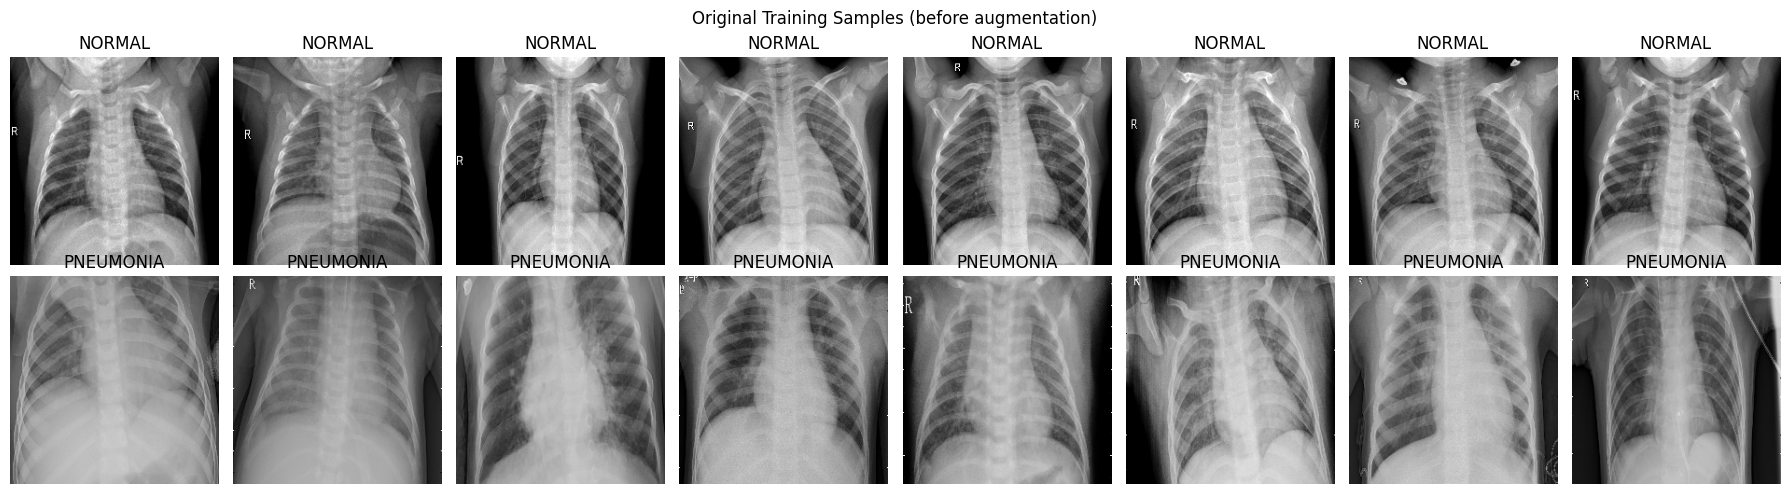

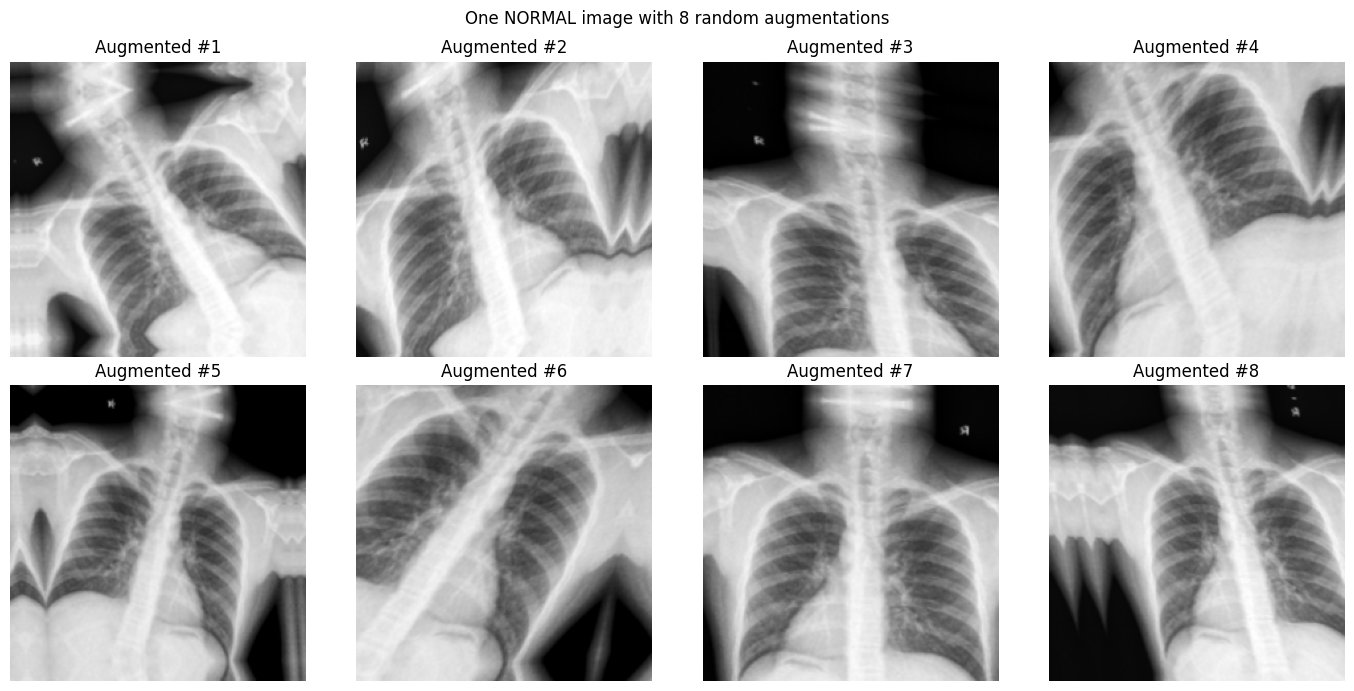

In [ ]:
normal_paths = train_paths[train_labels_raw == 0]
pneumonia_paths = train_paths[train_labels_raw == 1]

# For diagnostics only: effective per-epoch class counts under 1:1 sampled training.
balanced_epoch_count = steps_per_epoch * BATCH_SIZE // 2

print("Class distribution check")
print(f"  Train before balancing: NORMAL={(train_labels_raw==0).sum()}, PNEUMONIA={(train_labels_raw==1).sum()}")
print(f"  Train after balancing : NORMAL~{balanced_epoch_count}, PNEUMONIA~{balanced_epoch_count} (sampled)")
print(f"  Validation            : NORMAL={(val_labels_arr==0).sum()}, PNEUMONIA={(val_labels_arr==1).sum()}")

rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
normal_sample_paths = rng.choice(normal_paths, size=min(8, len(normal_paths)), replace=False)
pneumonia_sample_paths = rng.choice(pneumonia_paths, size=min(8, len(pneumonia_paths)), replace=False)

for i in range(8):
    if i < len(normal_sample_paths):
        img = keras.utils.load_img(normal_sample_paths[i], target_size=IMG_SIZE)
        axes[0, i].imshow(img)
        axes[0, i].set_title("NORMAL")
    axes[0, i].axis("off")

    if i < len(pneumonia_sample_paths):
        img = keras.utils.load_img(pneumonia_sample_paths[i], target_size=IMG_SIZE)
        axes[1, i].imshow(img)
        axes[1, i].set_title("PNEUMONIA")
    axes[1, i].axis("off")

plt.suptitle("Original Training Samples (before augmentation)")
plt.tight_layout()
plt.show()

sample_normal = keras.utils.load_img(normal_paths[0], target_size=IMG_SIZE)
sample_tensor = tf.expand_dims(tf.cast(keras.utils.img_to_array(sample_normal), tf.float32), axis=0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, ax in enumerate(axes.flat):
    aug_img = data_augmentation(sample_tensor, training=True)[0]
    aug_img = tf.clip_by_value(aug_img / 255.0, 0.0, 1.0)
    ax.imshow(aug_img)
    ax.set_title(f"Augmented #{idx+1}")
    ax.axis("off")

plt.suptitle("One NORMAL image with 8 random augmentations")
plt.tight_layout()
plt.show()

#### 3 - Helper Utilities

Define reusable serialization and metadata-saving helpers before training and evaluation.

In [ ]:
# Bind a notebook-local saver without redefining utility functions here.
save_model_with_meta = training_utils.make_model_saver(SAVE_DIR)

<hr style="height:6px;background-color:blue;border:none;">

### Phase 2 - CNN Model Without Augmentation

Define a regularized baseline CNN without in-graph augmentation and image rescaling for stable training.

In [ ]:
# Baseline CNN model (no transfer-learning backbone)
model_without_aug = model_utils.build_baseline_cnn(
    img_size=IMG_SIZE,
    augmentation_layer=None,
    learning_rate=1e-2,
    l2_reg=1e-4,
    name="baseline_pneumonia_cnn",
)
model_without_aug.summary()

Model: "baseline_pneumonia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 28, 28, 256)    │         1,02

 Total params: 1,209,121 (4.61 MB)

 Trainable params: 1,207,201 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
my_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=0.000001,
    ),
    keras.callbacks.ModelCheckpoint(
        BASELINE_WITHOUT_AUG_CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    keras.callbacks.TerminateOnNaN(),
]

class_weight = data_utils.compute_class_weights(train_labels_raw, strategy="balanced")
print("Class weights:", class_weight)


if BASELINE_WITHOUT_AUG_CHECKPOINT_PATH.exists():
    TRAINING = False
    print(f"Loading existing baseline checkpoint: {BASELINE_WITHOUT_AUG_CHECKPOINT_PATH}")
    best_model_without_aug = load_model(BASELINE_WITHOUT_AUG_CHECKPOINT_PATH)
    history = None
else:
    TRAINING = True
    history_model_without_aug = model_without_aug.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=my_callbacks,
        class_weight=class_weight,
    )
    print(f"Best baseline checkpoint saved to: {BASELINE_WITHOUT_AUG_CHECKPOINT_PATH}")

Class weights: {0: 1.9390444810543657, 1: 0.6737263880938752}
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 48s 158ms/step - accuracy: 0.8354 - auc: 0.9168 - loss: 0.4185 - pr_auc: 0.9650 - val_accuracy: 0.3073 - val_auc: 0.5453 - val_loss: 22.7731 - val_pr_auc: 0.7972 - learning_rate: 0.0100
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8932 - auc: 0.9575 - loss: 0.3020 - pr_auc: 0.9842 - val_accuracy: 0.2595 - val_auc: 0.5013 - val_loss: 69.1478 - val_pr_auc: 0.7456 - learning_rate: 0.0100
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9155 - auc: 0.9700 - loss: 0.2627 - pr_auc: 0.9887 - val_accuracy: 0.4618 - val_auc: 0.8682 - val_loss: 2.0939 - val_pr_auc: 0.9506 - learning_rate: 0.0100
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9337 - auc: 0.9788 - loss: 0.2257 - pr_auc: 0.9920 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 2.4486 - val_pr_auc: 0.7424 - learning_rate: 0.0100
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s

In [ ]:
## EVALUATION OF MODEL WITHOUT AUGMENTATION

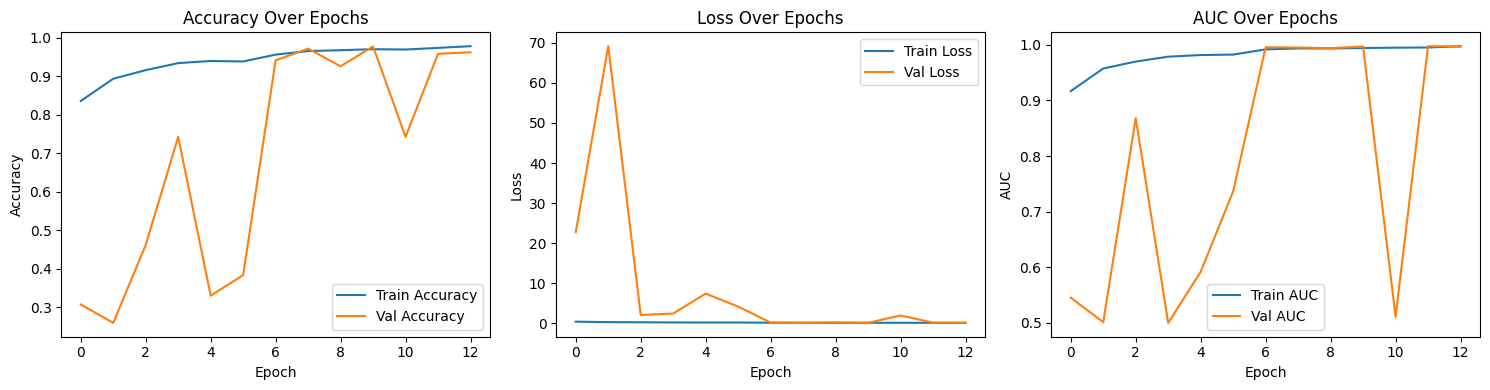

In [ ]:
# Plot training curves (loss, accuracy, and AUC)
if history_model_without_aug is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(history_model_without_aug.history["accuracy"], label="Train Accuracy")
    plt.plot(history_model_without_aug.history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history_model_without_aug.history["loss"], label="Train Loss")
    plt.plot(history_model_without_aug.history["val_loss"], label="Val Loss")
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history_model_without_aug.history["auc"], label="Train AUC")
    plt.plot(history_model_without_aug.history["val_auc"], label="Val AUC")
    plt.title("AUC Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
MODEL_TO_LOAD = BASELINE_WITHOUT_AUG_CHECKPOINT_PATH

if not MODEL_TO_LOAD.exists():
    raise FileNotFoundError(
        f"Model file not found at {MODEL_TO_LOAD}. Run training first."
    )
if TRAINING:
    best_model_without_aug = training_utils.load_model_compat(MODEL_TO_LOAD)

In [ ]:
# Threshold selection stage
print("Searching the best decision threshold on validation data (macro F1)...")

Searching the best decision threshold on validation data (macro F1)...


In [ ]:
# Threshold tuning on validation split
val_true_batches, val_prob_batches = [], []
for images, labels in val_ds:
    probs = best_model_without_aug.predict(images, verbose=0).ravel()
    val_prob_batches.append(probs)
    val_true_batches.append(labels.numpy().ravel())

val_true = np.concatenate(val_true_batches).astype(int)
val_prob = np.concatenate(val_prob_batches)

thresholds = np.linspace(0.05, 0.95, 91)
val_macro_f1_scores = []
for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    report_t = classification_report(
        val_true,
        val_pred_t,
        target_names=["NORMAL", "PNEUMONIA"],
        output_dict=True,
        zero_division=0,
    )
    macro_f1 = (report_t["NORMAL"]["f1-score"] + report_t["PNEUMONIA"]["f1-score"]) / 2
    val_macro_f1_scores.append(macro_f1)

best_threshold = float(thresholds[int(np.argmax(val_macro_f1_scores))])
print(f"Best threshold from validation split (macro F1): {best_threshold:.2f}")

Best threshold from validation split (macro F1): 0.70


Test ROC-AUC: 0.9212


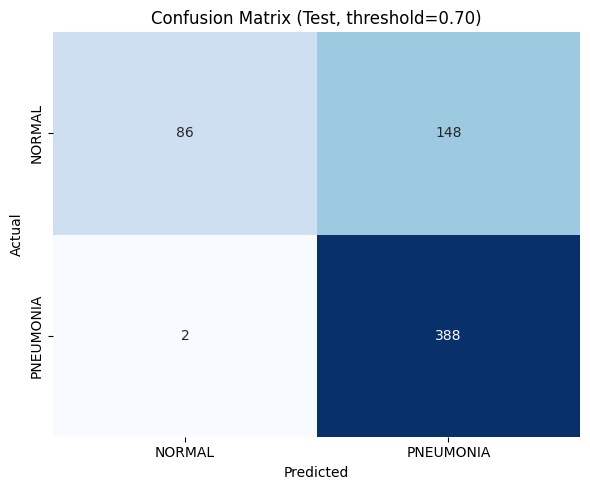

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       0.98      0.37      0.53       234
   PNEUMONIA       0.72      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.85      0.68      0.69       624
weighted avg       0.82      0.76      0.72       624



In [ ]:
# Predictions on test set
# best_threshold = 0.8
y_true_batches, y_prob_batches = [], []
for images, labels in test_ds:
    probs = best_model_without_aug.predict(images, verbose=0).ravel()
    y_prob_batches.append(probs)
    y_true_batches.append(labels.numpy().ravel())

y_true = np.concatenate(y_true_batches).astype(int)
y_prob = np.concatenate(y_prob_batches)
y_pred = (y_prob >= best_threshold).astype(int)

test_roc_auc = float(roc_auc_score(y_true, y_prob))
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Test, threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

print("Classification Report (Test):\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))

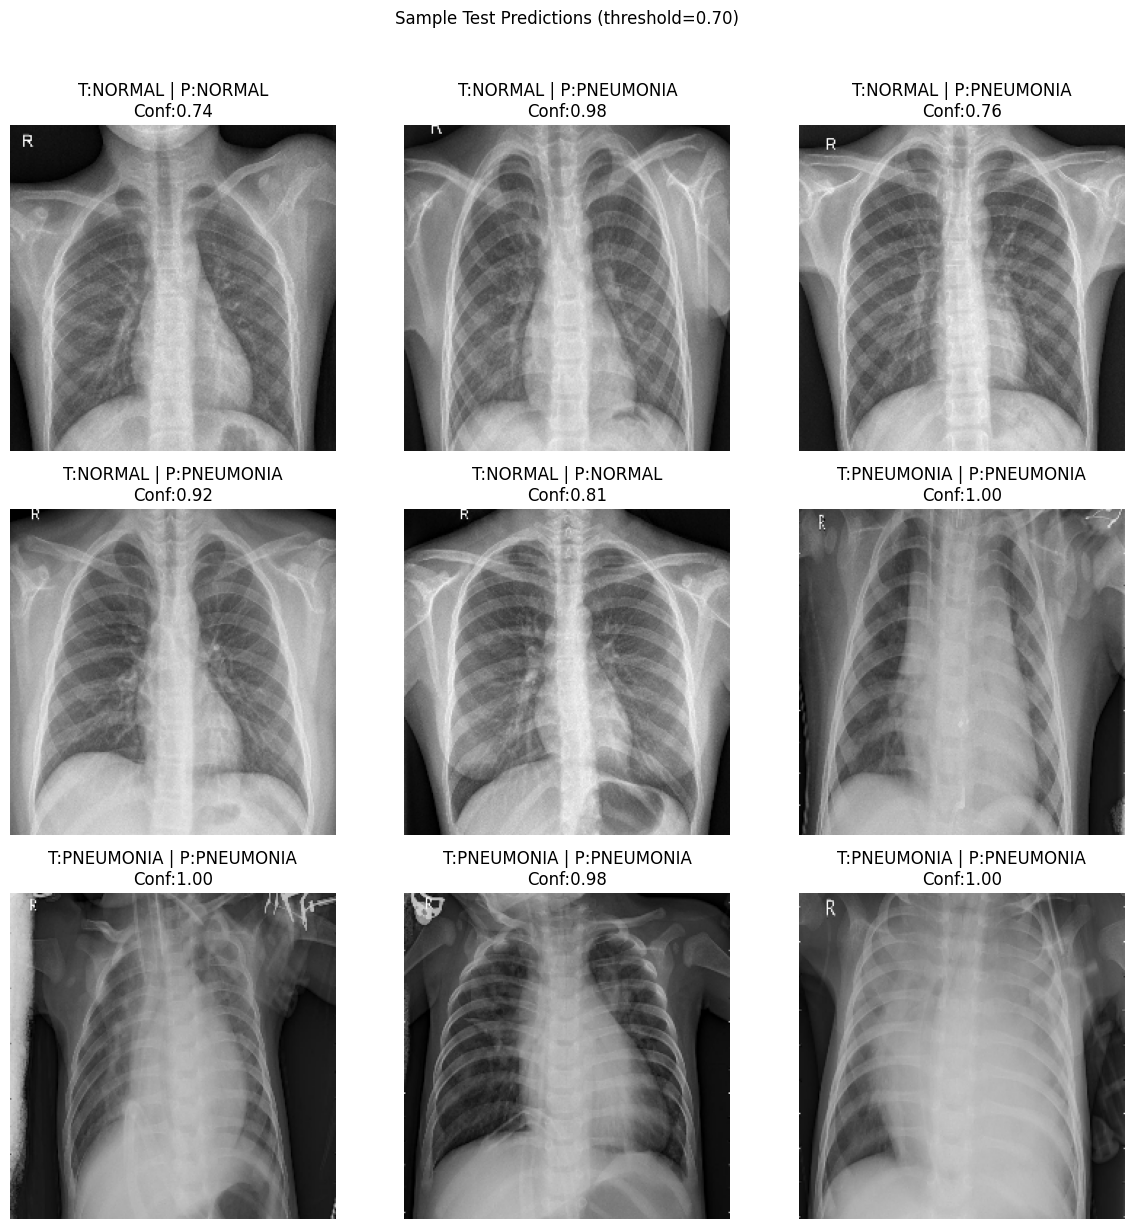

In [ ]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
normal_images, pneumonia_images = [], []
normal_true, pneumonia_true = [], []

for images, labels in test_ds:
    lbls = labels.numpy().ravel().astype(int)
    for i, lbl in enumerate(lbls):
        if lbl == 0 and len(normal_images) < 5:
            normal_images.append(images[i])
            normal_true.append(lbl)
        elif lbl == 1 and len(pneumonia_images) < 4:
            pneumonia_images.append(images[i])
            pneumonia_true.append(lbl)

    if len(normal_images) >= 5 and len(pneumonia_images) >= 4:
        break

sample_images = tf.stack(normal_images + pneumonia_images)
sample_true = np.array(normal_true + pneumonia_true, dtype=int)

sample_probs = best_model_without_aug.predict(sample_images, verbose=0).ravel()
sample_preds = (sample_probs >= best_threshold).astype(int)

idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

plt.figure(figsize=(12, 12))
plt.suptitle(f"Sample Test Predictions (threshold={best_threshold:.2f})", y=1.02)
for i in range(len(sample_images)):
    img = sample_images[i].numpy().astype("uint8")
    true_label = idx_to_class[int(sample_true[i])]
    pred_label = idx_to_class[int(sample_preds[i])]
    conf = sample_probs[i] if sample_preds[i] == 1 else (1 - sample_probs[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"T:{true_label} | P:{pred_label}\nConf:{conf:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

<hr style="height:6px;background-color:blue;border:none;">

### Phase 3 - CNN Model With Augmentation

Define a regularized baseline CNN with in-graph augmentation and image rescaling for stable training.

In [ ]:
# Baseline CNN model (no transfer-learning backbone)
# Compile the baseline model with robust classification metrics and gradient clipping for better optimization stability.

model = model_utils.build_baseline_cnn(
    img_size=IMG_SIZE,
    augmentation_layer=data_augmentation,
    learning_rate=1e-2,
    l2_reg=1e-4,
    name="pneumonia_cnn",
)
model.summary()

Model: "pneumonia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,16

 Total params: 1,209,121 (4.61 MB)

 Trainable params: 1,207,201 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
print("Balanced training split distribution (sampled):")
print(f"  NORMAL~{steps_per_epoch * BATCH_SIZE // 2}, PNEUMONIA~{steps_per_epoch * BATCH_SIZE // 2}, TOTAL~{steps_per_epoch * BATCH_SIZE}")
print("Validation split distribution:")
print(f"  NORMAL={int((val_labels_arr==0).sum())}, PNEUMONIA={int((val_labels_arr==1).sum())}, TOTAL={len(val_labels_arr)}")

print("Model is already compiled by model_utils.build_baseline_cnn with PR-AUC and gradient clipping.")

Balanced training split distribution (sampled):
  NORMAL~2368, PNEUMONIA~2368, TOTAL~4736
Validation split distribution:
  NORMAL=135, PNEUMONIA=389, TOTAL=524
Model is already compiled by model_utils.build_baseline_cnn with PR-AUC and gradient clipping.


In [ ]:
# Train with callbacks (early stopping, LR schedule, checkpointing) and resume from checkpoint when available.

my_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=0.000001,
    ),
    keras.callbacks.ModelCheckpoint(
        BASELINE_CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    keras.callbacks.TerminateOnNaN(),
]

class_weight = data_utils.compute_class_weights(train_labels_raw, strategy="balanced")
print("Class weights:", class_weight)

if BASELINE_CHECKPOINT_PATH.exists():
    TRAINING = False
    print(f"Loading existing baseline checkpoint: {BASELINE_CHECKPOINT_PATH}")
    best_model_with_aug = load_model(BASELINE_CHECKPOINT_PATH)
    history = None
else:
    TRAINING = True
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        steps_per_epoch=steps_per_epoch,
        callbacks=my_callbacks,
        class_weight=class_weight,
    )
    print(f"Best baseline checkpoint saved to: {BASELINE_CHECKPOINT_PATH}")

Class weights: {0: 1.9390444810543657, 1: 0.6737263880938752}
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.7587 - auc: 0.8559 - loss: 0.5128 - pr_auc: 0.9454 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 6.7284 - val_pr_auc: 0.7424 - learning_rate: 0.0100
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.8224 - auc: 0.9038 - loss: 0.4272 - pr_auc: 0.9619 - val_accuracy: 0.7424 - val_auc: 0.5074 - val_loss: 2.9796 - val_pr_auc: 0.7452 - learning_rate: 0.0100
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8339 - auc: 0.9136 - loss: 0.4043 - pr_auc: 0.9683 - val_accuracy: 0.7500 - val_auc: 0.7326 - val_loss: 1.3378 - val_pr_auc: 0.8499 - learning_rate: 0.0100
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8503 - auc: 0.9260 - loss: 0.3709 - pr_auc: 0.9726 - val_accuracy: 0.7691 - val_auc: 0.8409 - val_loss: 0.7525 - val_pr_auc: 0.9280 - learning_rate: 0.0100
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 61

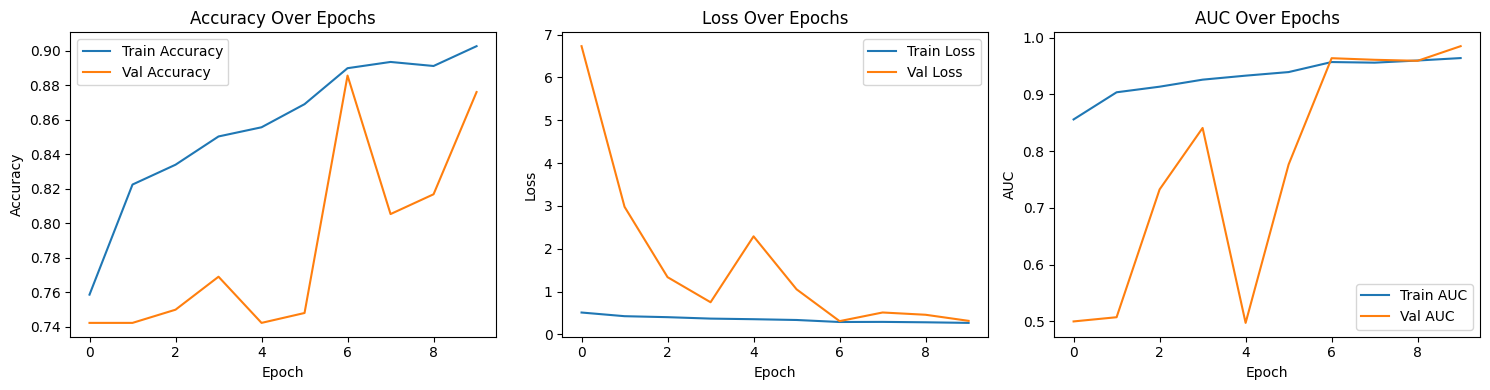

In [ ]:
# Load the best checkpoint, tune decision threshold on validation data, and report test-set performance.

# Plot training curves (loss, accuracy, and AUC)
if history is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history["auc"], label="Train AUC")
    plt.plot(history.history["val_auc"], label="Val AUC")
    plt.title("AUC Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Baseline checkpoint loading stage
print("Loading baseline checkpoint for threshold tuning and test evaluation...")

Loading baseline checkpoint for threshold tuning and test evaluation...


In [ ]:
MODEL_TO_LOAD = BASELINE_CHECKPOINT_PATH
if not MODEL_TO_LOAD.exists():
    raise FileNotFoundError(
        f"Model file not found at {MODEL_TO_LOAD}. Run training first."
    )
if TRAINING:
    best_model_with_aug = training_utils.load_model_compat(MODEL_TO_LOAD)
    
print(f"Loaded model from: {MODEL_TO_LOAD}")
print(f"Model input shape: {best_model_with_aug.input_shape}")
print(f"Model output shape: {best_model_with_aug.output_shape}")

Loaded model from: /content/drive/MyDrive/saved_models/baseline_best_checkpoint.keras
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 1)


In [ ]:
# Threshold selection stage
print("Searching the best decision threshold on validation data (macro F1)...")

Searching the best decision threshold on validation data (macro F1)...


In [ ]:
# Threshold tuning on validation split
val_true_batches, val_prob_batches = [], []
for images, labels in val_ds:
    probs = best_model_with_aug.predict(images, verbose=0).ravel()
    val_prob_batches.append(probs)
    val_true_batches.append(labels.numpy().ravel())

val_true = np.concatenate(val_true_batches).astype(int)
val_prob = np.concatenate(val_prob_batches)

thresholds = np.linspace(0.05, 0.95, 91)
val_macro_f1_scores = []
for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    report_t = classification_report(
        val_true,
        val_pred_t,
        target_names=["NORMAL", "PNEUMONIA"],
        output_dict=True,
        zero_division=0,
    )
    macro_f1 = (report_t["NORMAL"]["f1-score"] + report_t["PNEUMONIA"]["f1-score"]) / 2
    val_macro_f1_scores.append(macro_f1)

best_threshold = float(thresholds[int(np.argmax(val_macro_f1_scores))])
print(f"Best threshold from validation split (macro F1): {best_threshold:.2f}")

Best threshold from validation split (macro F1): 0.33


Test ROC-AUC: 0.8930


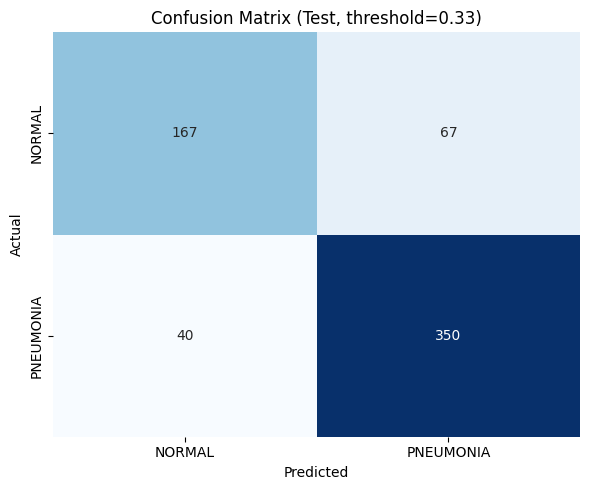

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       0.81      0.71      0.76       234
   PNEUMONIA       0.84      0.90      0.87       390

    accuracy                           0.83       624
   macro avg       0.82      0.81      0.81       624
weighted avg       0.83      0.83      0.83       624



In [ ]:
# Predictions on test set
# best_threshold = 0.8
y_true_batches, y_prob_batches = [], []
for images, labels in test_ds:
    probs = best_model_with_aug.predict(images, verbose=0).ravel()
    y_prob_batches.append(probs)
    y_true_batches.append(labels.numpy().ravel())

y_true = np.concatenate(y_true_batches).astype(int)
y_prob = np.concatenate(y_prob_batches)
y_pred = (y_prob >= best_threshold).astype(int)

test_roc_auc = float(roc_auc_score(y_true, y_prob))
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Test, threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

print("Classification Report (Test):\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))

In [ ]:
# Persist baseline model artifacts and metadata
report = classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    output_dict=True,
    zero_division=0,
)

baseline_metrics = {
    "accuracy": float((y_pred == y_true).mean()),
    "auc": test_roc_auc,
    "precision": float(report["PNEUMONIA"]["precision"]),
    "recall": float(report["PNEUMONIA"]["recall"]),
    "f1": float(report["PNEUMONIA"]["f1-score"]),
}

baseline_hyperparams = {
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "optimizer": "Adam",
    "learning_rate": 1e-4,
    "balanced_sampling": "sample_from_datasets(weights=[0.5, 0.5])",
    "steps_per_epoch": steps_per_epoch,
    "threshold_search_range": [0.05, 0.95, 91],
}

if "history" not in globals():
    history = None

save_model_with_meta(best_model_with_aug, "baseline_cnn", baseline_metrics, history, baseline_hyperparams, best_threshold)

print("\nSummary:")
print("- Validation now uses a large split from dataset/train instead of the tiny val folder.")
print("- Training uses balanced on-the-fly sampling with repeat + sample_from_datasets.")
print("- Decision threshold tuned on validation split before final test evaluation.")

Saved model to: /content/drive/MyDrive/saved_models/baseline_cnn.keras
Saved metadata to: /content/drive/MyDrive/saved_models/baseline_cnn_meta.json

Summary:
- Validation now uses a large split from dataset/train instead of the tiny val folder.
- Training uses balanced on-the-fly sampling with repeat + sample_from_datasets.
- Decision threshold tuned on validation split before final test evaluation.


NORMAL samples: 234 | PNEUMONIA samples: 390


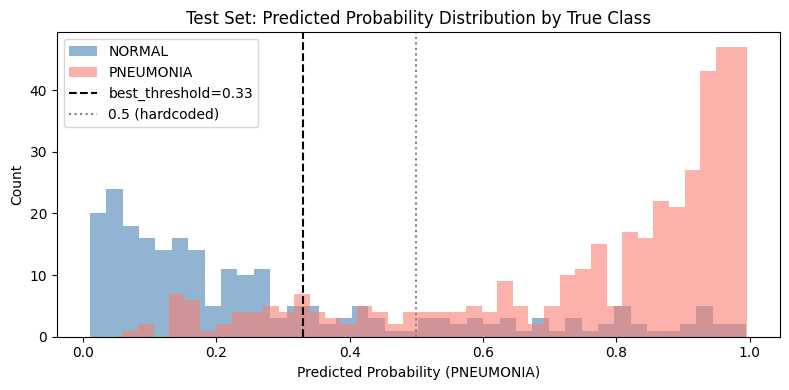

In [ ]:
# Diagnostic: probability distribution by true class on test set
from IPython.display import display

# Flatten to 1D arrays to avoid shape/indexing edge cases.
y_true_arr = np.asarray(y_true).reshape(-1)
y_prob_arr = np.asarray(y_prob).reshape(-1)

normal_probs = y_prob_arr[y_true_arr == 0]
pneumonia_probs = y_prob_arr[y_true_arr == 1]

print(f"NORMAL samples: {normal_probs.size} | PNEUMONIA samples: {pneumonia_probs.size}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(normal_probs, bins=40, alpha=0.6, label="NORMAL", color="steelblue")
ax.hist(pneumonia_probs, bins=40, alpha=0.6, label="PNEUMONIA", color="salmon")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"best_threshold={best_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="0.5 (hardcoded)")
ax.set_xlabel("Predicted Probability (PNEUMONIA)")
ax.set_ylabel("Count")
ax.set_title("Test Set: Predicted Probability Distribution by True Class")
ax.legend()
fig.tight_layout()

display(fig)
plt.close(fig)

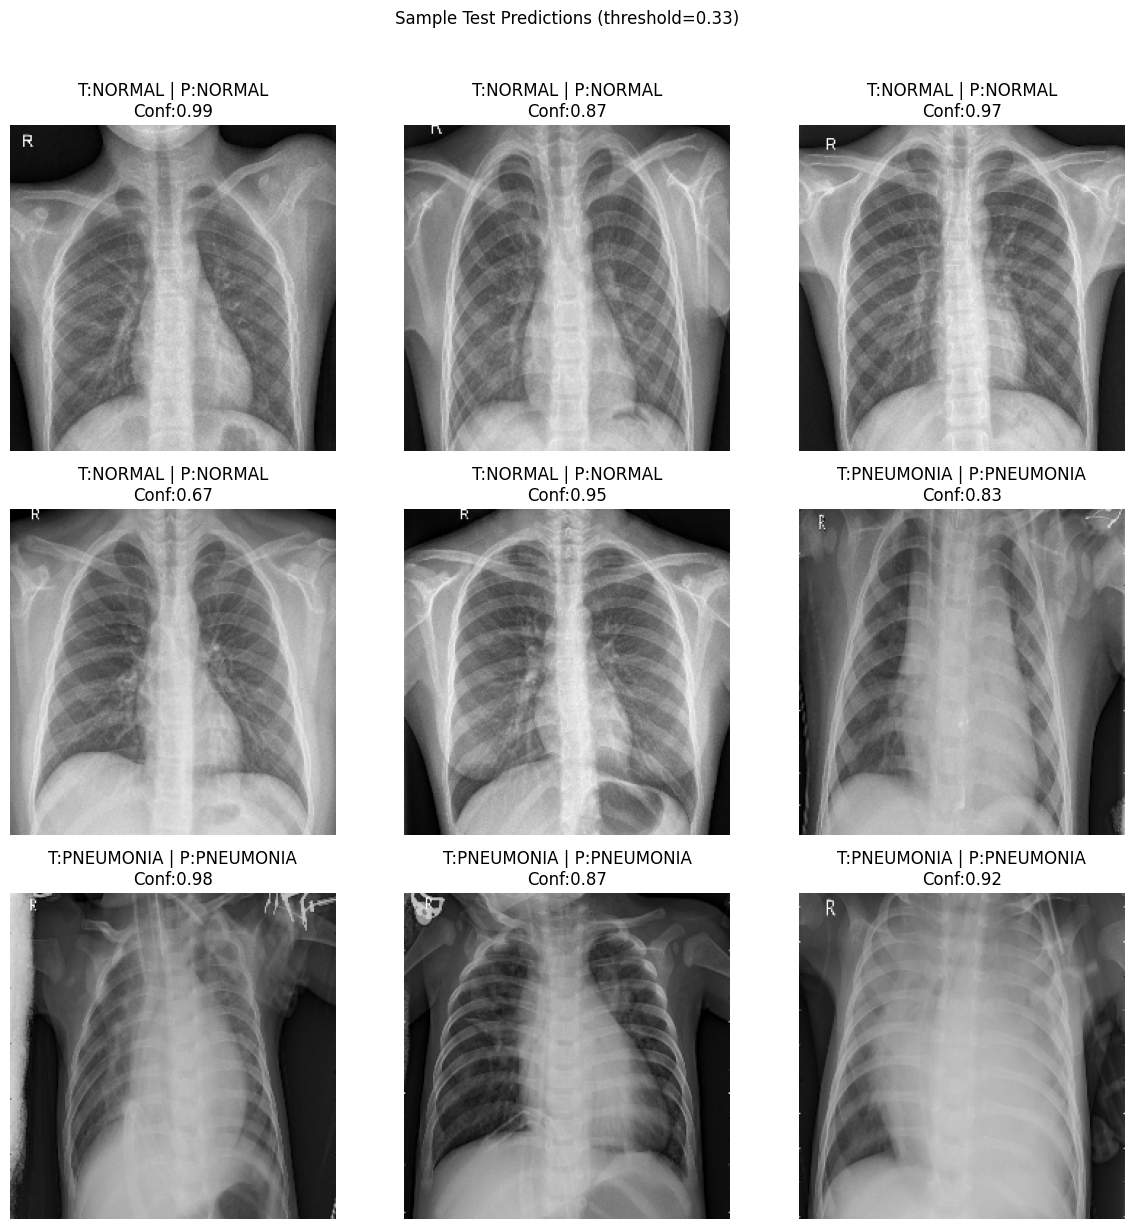

In [ ]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
normal_images, pneumonia_images = [], []
normal_true, pneumonia_true = [], []

for images, labels in test_ds:
    lbls = labels.numpy().ravel().astype(int)
    for i, lbl in enumerate(lbls):
        if lbl == 0 and len(normal_images) < 5:
            normal_images.append(images[i])
            normal_true.append(lbl)
        elif lbl == 1 and len(pneumonia_images) < 4:
            pneumonia_images.append(images[i])
            pneumonia_true.append(lbl)

    if len(normal_images) >= 5 and len(pneumonia_images) >= 4:
        break

sample_images = tf.stack(normal_images + pneumonia_images)
sample_true = np.array(normal_true + pneumonia_true, dtype=int)

sample_probs = best_model_with_aug.predict(sample_images, verbose=0).ravel()
sample_preds = (sample_probs >= best_threshold).astype(int)

idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

plt.figure(figsize=(12, 12))
plt.suptitle(f"Sample Test Predictions (threshold={best_threshold:.2f})", y=1.02)
for i in range(len(sample_images)):
    img = sample_images[i].numpy().astype("uint8")
    true_label = idx_to_class[int(sample_true[i])]
    pred_label = idx_to_class[int(sample_preds[i])]
    conf = sample_probs[i] if sample_preds[i] == 1 else (1 - sample_probs[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"T:{true_label} | P:{pred_label}\nConf:{conf:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8) Overfitting Countermeasures Used

1. Medically safe data augmentation (`RandomFlip`, mild `RandomRotation`, mild `RandomTranslation`, mild `RandomZoom`, mild `RandomShear`, mild `RandomBrightness`).
2. Batch normalization after each convolution block.
3. Progressive dropout in conv blocks plus classifier dropout.
4. L2 regularization in convolution and dense layers.
5. Gradient clipping (`clipnorm=1.0`) in Adam optimizer.
6. Conservative optimizer settings (`learning_rate=0.001`, `label_smoothing=0.02`) for smoother convergence.
7. Early stopping and LR scheduling on `val_accuracy`.

<hr style="height:6px;background-color:blue;border:none;">

### Phase 4 - Baseline CNN Hyperparameter Tuning (Keras Tuner)

Search for better hyperparameters with Bayesian optimization, then train/evaluate the best tuned model.

In [ ]:
MAX_TRIALS = 15
TUNER_EPOCHS = 12
TUNER_SEED = 42

# Ensure class weights exist even if cells are run out of order.
if "class_weight" not in globals() or class_weight is None:
    class_weight = data_utils.compute_class_weights(train_labels_raw, strategy="balanced")


def _load_image_for_tuning(path, label):
    return data_utils.load_image(path, label, IMG_SIZE)


# Build once, then only re-batch per trial to avoid remapping/reloading images.
_train_ds_unbatched = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels_raw.astype("float32")))
    .shuffle(len(train_paths), seed=TUNER_SEED, reshuffle_each_iteration=True)
    .map(_load_image_for_tuning, num_parallel_calls=tf.data.AUTOTUNE)
)
_val_ds_unbatched = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels_arr.astype("float32")))
    .map(_load_image_for_tuning, num_parallel_calls=tf.data.AUTOTUNE)
)


def _rebatch_trial_datasets(batch_size):
    train_ds_trial = _train_ds_unbatched.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds_trial = _val_ds_unbatched.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return train_ds_trial, val_ds_trial


def build_tunable_model(hp):
    return model_utils.build_baseline_model_from_hp(
        hp,
        img_size=IMG_SIZE,
        augmentation_layer=data_augmentation,
    )


class PneumoniaTuner(kt.BayesianOptimization):
    def run_trial(self, trial, *args, **kwargs):
        hp = trial.hyperparameters
        batch_size = hp.Choice("batch_size", [16, 32, 48])

        train_ds_trial, val_ds_trial = _rebatch_trial_datasets(batch_size)
        trial_steps = max(1, int(np.ceil(len(train_paths) / batch_size)))

        trial_callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_accuracy",
                mode="max",
                patience=3,
                restore_best_weights=True,
            )
        ]

        kwargs.update(
            {
                "x": train_ds_trial,
                "validation_data": val_ds_trial,
                "epochs": TUNER_EPOCHS,
                "steps_per_epoch": trial_steps,
                "callbacks": trial_callbacks,
                "class_weight": class_weight,
                "verbose": 1,
            }
        )
        return super().run_trial(trial, *args, **kwargs)

In [ ]:
tuned_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
    ),
    keras.callbacks.ModelCheckpoint(
        TUNED_CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    keras.callbacks.TerminateOnNaN(),
]

tuner = PneumoniaTuner(
    hypermodel=build_tunable_model,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=MAX_TRIALS,
    directory=str(SAVE_DIR),
    project_name="baseline_cnn_tuning",
    overwrite=True,
)

tuner.search()
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)
print("Best batch_size:", best_hp.get("batch_size"))

Trial 15 Complete [00h 02m 21s]
val_accuracy: 0.8950381875038147

Best val_accuracy So Far: 0.9484732747077942
Total elapsed time: 00h 31m 44s
Best hyperparameters: {'num_blocks': 5, 'start_filters': 64, 'kernel_size': 3, 'block_dropout': 0.25, 'l2_reg': 0.01, 'dense_units': 128, 'dense_dropout': 0.4, 'learning_rate': 0.0001, 'batch_size': 16}
Best batch_size: 16


In [ ]:
# Train (or resume) tuned baseline model using the best tuned batch size
best_batch_size = best_hp.get("batch_size") or 32
train_ds_best, val_ds_best = _rebatch_trial_datasets(best_batch_size)
best_steps_per_epoch = max(1, int(np.ceil(len(train_paths) / best_batch_size)))

if TUNED_CHECKPOINT_PATH.exists():
    print(f"Loading existing tuned checkpoint: {TUNED_CHECKPOINT_PATH}")
    baseline_tuned_model = load_model(TUNED_CHECKPOINT_PATH)
    baseline_tuned_history = None
else:
    baseline_tuned_model = model_utils.build_baseline_model_from_hp(
        best_hp,
        img_size=IMG_SIZE,
        augmentation_layer=data_augmentation,
    )
    baseline_tuned_history = baseline_tuned_model.fit(
        train_ds_best,
        validation_data=val_ds_best,
        epochs=EPOCHS,
        steps_per_epoch=best_steps_per_epoch,
        callbacks=tuned_callbacks,
        class_weight=class_weight,
        verbose=1,
    )
    print(f"Best tuned checkpoint saved to: {TUNED_CHECKPOINT_PATH}")

Epoch 1/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.8235 - auc: 0.9012 - loss: 2.1077 - pr_auc: 0.9635 - val_accuracy: 0.7424 - val_auc: 0.5000 - val_loss: 6.0079 - val_pr_auc: 0.7424 - learning_rate: 1.0000e-04
Epoch 2/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8666 - auc: 0.9382 - loss: 1.4322 - pr_auc: 0.9762 - val_accuracy: 0.8511 - val_auc: 0.9767 - val_loss: 1.2682 - val_pr_auc: 0.9924 - learning_rate: 1.0000e-04
Epoch 3/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.8764 - auc: 0.9468 - loss: 1.0496 - pr_auc: 0.9809 - val_accuracy: 0.7882 - val_auc: 0.9776 - val_loss: 1.1339 - val_pr_auc: 0.9925 - learning_rate: 1.0000e-04
Epoch 4/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.8887 - auc: 0.9573 - loss: 0.8018 - pr_auc: 0.9840 - val_accuracy: 0.8473 - val_auc: 0.9875 - val_loss: 0.8508 - val_pr_auc: 0.9957 - learning_rate: 1.0000e-04
Epoch 5/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9072 - auc: 0.9658 -

In [ ]:
# Threshold tuning (macro F1) and test evaluation for tuned model
val_true_batches, val_prob_batches = [], []
for images, labels in val_ds:
    probs = baseline_tuned_model.predict(images, verbose=0).ravel()
    val_prob_batches.append(probs)
    val_true_batches.append(labels.numpy().ravel())

val_true = np.concatenate(val_true_batches).astype(int)
val_prob = np.concatenate(val_prob_batches)
thresholds = np.linspace(0.05, 0.95, 91)
val_macro_f1_scores = []
for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    report_t = classification_report(
        val_true,
        val_pred_t,
        target_names=["NORMAL", "PNEUMONIA"],
        output_dict=True,
        zero_division=0,
    )
    macro_f1 = (report_t["NORMAL"]["f1-score"] + report_t["PNEUMONIA"]["f1-score"]) / 2
    val_macro_f1_scores.append(macro_f1)
baseline_tuned_threshold = float(thresholds[int(np.argmax(val_macro_f1_scores))])

y_true_batches, y_prob_batches = [], []
for images, labels in test_ds:
    probs = baseline_tuned_model.predict(images, verbose=0).ravel()
    y_prob_batches.append(probs)
    y_true_batches.append(labels.numpy().ravel())
y_true = np.concatenate(y_true_batches).astype(int)
y_prob = np.concatenate(y_prob_batches)
y_pred = (y_prob >= baseline_tuned_threshold).astype(int)

tuned_report = classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    output_dict=True,
    zero_division=0,
)
baseline_tuned_metrics = {
    "accuracy": float((y_pred == y_true).mean()),
    "auc": float(roc_auc_score(y_true, y_prob)),
    "precision": float(tuned_report["PNEUMONIA"]["precision"]),
    "recall": float(tuned_report["PNEUMONIA"]["recall"]),
    "f1": float(tuned_report["PNEUMONIA"]["f1-score"]),
}

print(f"Tuned model threshold (macro F1): {baseline_tuned_threshold:.2f}")
print(f"Tuned model test ROC-AUC: {baseline_tuned_metrics['auc']:.4f}")

Tuned model threshold (macro F1): 0.62
Tuned model test ROC-AUC: 0.9420


In [ ]:
# Save tuned model and metadata
save_model_with_meta(
    baseline_tuned_model,
    "baseline_cnn_tuned",
    baseline_tuned_metrics,
    baseline_tuned_history,
    best_hp.values,
    baseline_tuned_threshold,
)
print(f"Saved tuned baseline model with threshold {baseline_tuned_threshold:.2f}")

Saved model to: /content/drive/MyDrive/saved_models/baseline_cnn_tuned.keras
Saved metadata to: /content/drive/MyDrive/saved_models/baseline_cnn_tuned_meta.json
Saved tuned baseline model with threshold 0.62


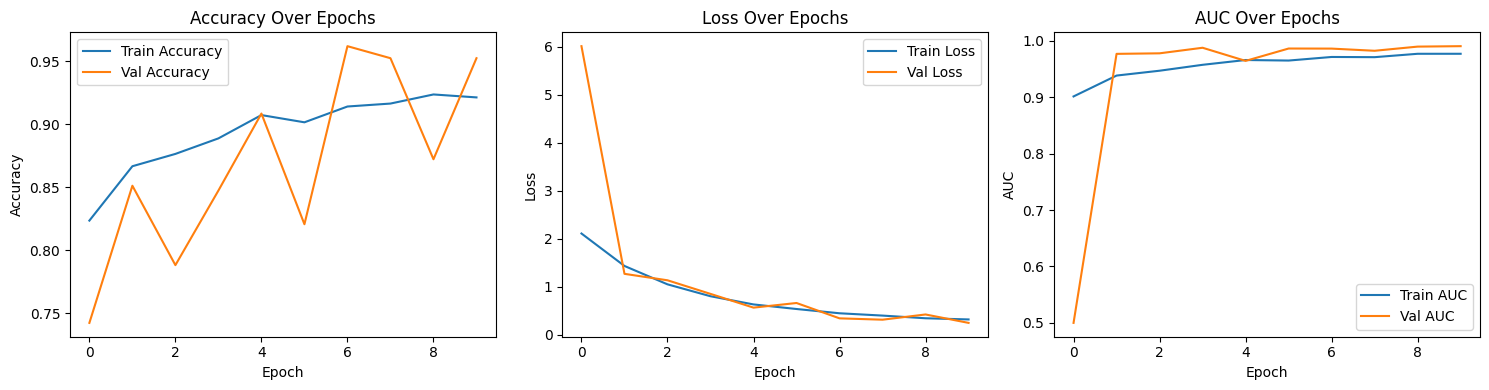

In [ ]:
# Plot training curves (loss, accuracy, and AUC)
if baseline_tuned_history is None:
    print("Training history is unavailable because model was loaded from checkpoint.")
else:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(baseline_tuned_history.history["accuracy"], label="Train Accuracy")
    plt.plot(baseline_tuned_history.history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(baseline_tuned_history.history["loss"], label="Train Loss")
    plt.plot(baseline_tuned_history.history["val_loss"], label="Val Loss")
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(baseline_tuned_history.history["auc"], label="Train AUC")
    plt.plot(baseline_tuned_history.history["val_auc"], label="Val AUC")
    plt.title("AUC Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Threshold tuning on validation split
val_true_batches, val_prob_batches = [], []
for images, labels in val_ds:
    probs = baseline_tuned_model.predict(images, verbose=0).ravel()
    val_prob_batches.append(probs)
    val_true_batches.append(labels.numpy().ravel())

val_true = np.concatenate(val_true_batches).astype(int)
val_prob = np.concatenate(val_prob_batches)

thresholds = np.linspace(0.05, 0.95, 91)
val_macro_f1_scores = []
for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    report_t = classification_report(
        val_true,
        val_pred_t,
        target_names=["NORMAL", "PNEUMONIA"],
        output_dict=True,
        zero_division=0,
    )
    macro_f1 = (report_t["NORMAL"]["f1-score"] + report_t["PNEUMONIA"]["f1-score"]) / 2
    val_macro_f1_scores.append(macro_f1)

best_threshold = float(thresholds[int(np.argmax(val_macro_f1_scores))])
print(f"Best threshold from validation split (macro F1): {best_threshold:.2f}")

Best threshold from validation split (macro F1): 0.62


Test ROC-AUC: 0.9420


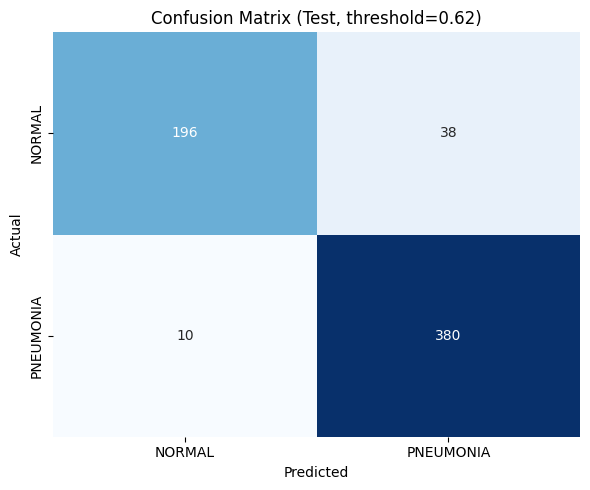

Classification Report (Test):

              precision    recall  f1-score   support

      NORMAL       0.95      0.84      0.89       234
   PNEUMONIA       0.91      0.97      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.91      0.92       624
weighted avg       0.92      0.92      0.92       624



In [ ]:
# Predictions on test set
# best_threshold = 0.8
y_true_batches, y_prob_batches = [], []
for images, labels in test_ds:
    probs = baseline_tuned_model.predict(images, verbose=0).ravel()
    y_prob_batches.append(probs)
    y_true_batches.append(labels.numpy().ravel())

y_true = np.concatenate(y_true_batches).astype(int)
y_prob = np.concatenate(y_prob_batches)
y_pred = (y_prob >= best_threshold).astype(int)

test_roc_auc = float(roc_auc_score(y_true, y_prob))
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Test, threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

print("Classification Report (Test):\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], zero_division=0))

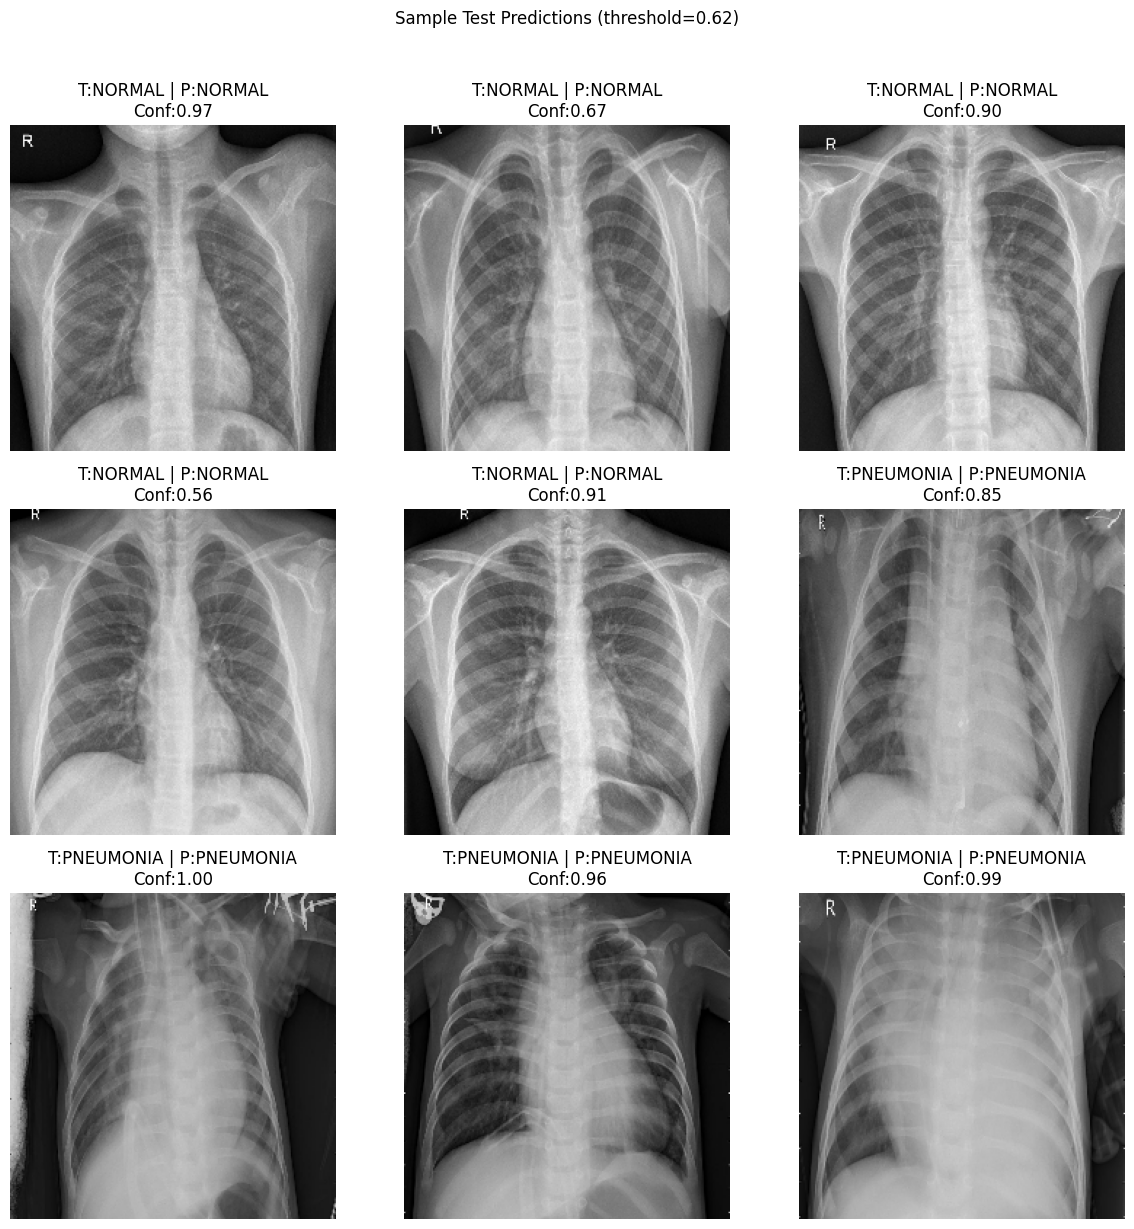

In [ ]:
# Show sample predictions from test set (balanced sample: 5 NORMAL + 4 PNEUMONIA)
normal_images, pneumonia_images = [], []
normal_true, pneumonia_true = [], []

for images, labels in test_ds:
    lbls = labels.numpy().ravel().astype(int)
    for i, lbl in enumerate(lbls):
        if lbl == 0 and len(normal_images) < 5:
            normal_images.append(images[i])
            normal_true.append(lbl)
        elif lbl == 1 and len(pneumonia_images) < 4:
            pneumonia_images.append(images[i])
            pneumonia_true.append(lbl)

    if len(normal_images) >= 5 and len(pneumonia_images) >= 4:
        break

sample_images = tf.stack(normal_images + pneumonia_images)
sample_true = np.array(normal_true + pneumonia_true, dtype=int)

sample_probs = baseline_tuned_model.predict(sample_images, verbose=0).ravel()
sample_preds = (sample_probs >= best_threshold).astype(int)

idx_to_class = {0: "NORMAL", 1: "PNEUMONIA"}

plt.figure(figsize=(12, 12))
plt.suptitle(f"Sample Test Predictions (threshold={best_threshold:.2f})", y=1.02)
for i in range(len(sample_images)):
    img = sample_images[i].numpy().astype("uint8")
    true_label = idx_to_class[int(sample_true[i])]
    pred_label = idx_to_class[int(sample_preds[i])]
    conf = sample_probs[i] if sample_preds[i] == 1 else (1 - sample_probs[i])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"T:{true_label} | P:{pred_label}\nConf:{conf:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)